**Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

**Import Dataset**

In [ ]:
df = pd.read_csv("/content/Telco-Customer-Churn.csv")
print("Rows, cols:", df.shape)
df.head()

Rows, cols: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Basic EDA**

In [ ]:
print(df.info())
print("\nMissing values per column:")
print(df.isna().sum())
print("\nTarget distribution (Churn):")
print(df['Churn'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Preprocess pipeline**

In [ ]:
data = df.copy()

data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'] = data['TotalCharges'].fillna(0)

data = data.drop(columns=['customerID'])

y = (data['Churn'] == 'Yes').astype(int)
X = data.drop(columns=['Churn'])

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

num_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print("Processed shapes:", X_train_proc.shape, X_test_proc.shape)

Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Processed shapes: (5634, 45) (1409, 45)


**Build a Keras ANN model**

In [ ]:
input_shape = X_train_proc.shape[1]

def build_model(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
    )
    return model

model = build_model(input_shape)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │        11,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,577 (221.00 KB)

 Trainable params: 55,809 (218.00 KB)

 Non-trainable params: 768 (3.00 KB)

**Training with callbacks**

In [ ]:
es = callbacks.EarlyStopping(monitor='val_auc', patience=8, mode='max', restore_best_weights=True)
mc = callbacks.ModelCheckpoint('/content/best_telco_model.h5', monitor='val_auc', save_best_only=True, mode='max')

class_weight = {0:1, 1:3.5}

history = model.fit(
    X_train_proc, y_train,
    validation_split=0.15,
    epochs=150,
    batch_size=64,
    callbacks=[es, mc],
    verbose=2,
    class_weight=class_weight
)

Epoch 1/150


75/75 - 9s - 125ms/step - accuracy: 0.6633 - auc: 0.7930 - loss: 0.9087 - val_accuracy: 0.7435 - val_auc: 0.7994 - val_loss: 0.5624
Epoch 2/150


75/75 - 0s - 4ms/step - accuracy: 0.7295 - auc: 0.8343 - loss: 0.8296 - val_accuracy: 0.7151 - val_auc: 0.8057 - val_loss: 0.5453
Epoch 3/150


75/75 - 0s - 4ms/step - accuracy: 0.7258 - auc: 0.8386 - loss: 0.8147 - val_accuracy: 0.7128 - val_auc: 0.8106 - val_loss: 0.5318
Epoch 4/150
75/75 - 0s - 4ms/step - accuracy: 0.7228 - auc: 0.8378 - loss: 0.8177 - val_accuracy: 0.6950 - val_auc: 0.8096 - val_loss: 0.5501
Epoch 5/150
75/75 - 0s - 4ms/step - accuracy: 0.7304 - auc: 0.8462 - loss: 0.7966 - val_accuracy: 0.6820 - val_auc: 0.8091 - val_loss: 0.5565
Epoch 6/150
75/75 - 0s - 4ms/step - accuracy: 0.7266 - auc: 0.8442 - loss: 0.8006 - val_accuracy: 0.6809 - val_auc: 0.8070 - val_loss: 0.5613
Epoch 7/150
75/75 - 0s - 4ms/step - accuracy: 0.7314 - auc: 0.8516 - loss: 0.7809 - val_accuracy: 0.6797 - val_auc: 0.8054 - val_loss: 0.5700
Epoch 8/150
75/75 - 0s - 4ms/step - accuracy: 0.7291 - auc: 0.8488 - loss: 0.7882 - val_accuracy: 0.6749 - val_auc: 0.8056 - val_loss: 0.5756
Epoch 9/150
75/75 - 0s - 4ms/step - accuracy: 0.7402 - auc: 0.8545 - loss: 0.7727 - val_accuracy: 0.6785 - val_auc: 0.8089 - val_loss: 0.6038
Epoch 10/150
75/75

75/75 - 0s - 5ms/step - accuracy: 0.7377 - auc: 0.8573 - loss: 0.7656 - val_accuracy: 0.6738 - val_auc: 0.8111 - val_loss: 0.5886
Epoch 12/150
75/75 - 0s - 4ms/step - accuracy: 0.7423 - auc: 0.8606 - loss: 0.7602 - val_accuracy: 0.6761 - val_auc: 0.8063 - val_loss: 0.5816
Epoch 13/150
75/75 - 0s - 4ms/step - accuracy: 0.7479 - auc: 0.8587 - loss: 0.7625 - val_accuracy: 0.6749 - val_auc: 0.8049 - val_loss: 0.5904
Epoch 14/150
75/75 - 0s - 4ms/step - accuracy: 0.7343 - auc: 0.8554 - loss: 0.7668 - val_accuracy: 0.6785 - val_auc: 0.8049 - val_loss: 0.5808
Epoch 15/150
75/75 - 0s - 4ms/step - accuracy: 0.7431 - auc: 0.8604 - loss: 0.7569 - val_accuracy: 0.6537 - val_auc: 0.8017 - val_loss: 0.6112
Epoch 16/150
75/75 - 0s - 4ms/step - accuracy: 0.7498 - auc: 0.8633 - loss: 0.7429 - val_accuracy: 0.6655 - val_auc: 0.8018 - val_loss: 0.5960
Epoch 17/150
75/75 - 0s - 4ms/step - accuracy: 0.7425 - auc: 0.8645 - loss: 0.7407 - val_accuracy: 0.6726 - val_auc: 0.8043 - val_loss: 0.6009
Epoch 18/150

**Prediction and Metrices**

In [ ]:
y_pred_prob = model.predict(X_test_proc).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Test AUC:", roc_auc_score(y_test, y_pred_prob))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Test AUC: 0.8375029063008603

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.68      0.78      1035
           1       0.48      0.83      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.72      0.74      1409



**Plot**

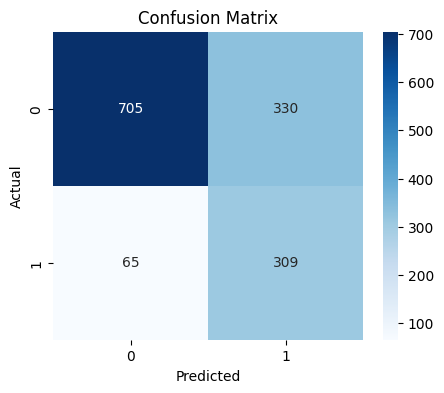

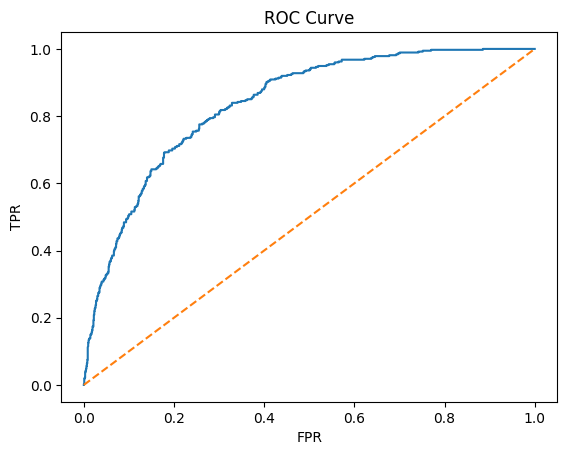

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')

# ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve')
plt.show()